<div style="background-color:#1e3799; padding: 20px; border-radius: 10px; border-left: 10px solid #f6b93b;">
    <h1 style="color:white; margin:0; font-family: sans-serif; font-size: 30px;">
        🚀 DỰ ÁN PHÁT TRIỂN CHIẾN LƯỢC GIAO DỊCH ĐỊNH LƯỢNG
    </h1>
    <h3 style="color:#dff9fb; margin-top:10px; font-style: italic;">
        Dự án: ADX Volatility Straddle
    </h3>
    <p style="color:white;">
        <strong>Người thực hiện:</strong> Lã Đức Duy <br>
        <strong>Thời gian thực hiện:</strong> 24/12/2025 - 29/12/2025
    </p>
</div>

# <span style="color:#0a3d62; border-bottom: 4px solid #0a3d62;">📋 Giới thiệu & Tóm tắt Dự án (Executive Summary)</span>

**1. Mục tiêu (Objective):**
Xây dựng và kiểm thử chiến lược giao dịch tự động **"ADX Volatility Straddle"** trên cặp tài sản **ETH/USDT** khung thời gian **30 phút (M30)**.
* **Triết lý:** Tận dụng hành vi giá lặp lại (Recurring behaviors) trong các khung giờ biến động mạnh để tìm kiếm lợi nhuận.
* **Trọng tâm:** Tối giản hóa quy tắc vào lệnh (Entry) để tập trung nguồn lực vào **Quản lý vốn (Capital Management)** và **Quản trị rủi ro (Risk Management)**.
* **KPI:** Kiểm soát mức sụt giảm tài khoản tối đa (**Max Drawdown**) **dưới 20%**, **Sharpe ratio > 0.3** và **Annualized return (tỷ suất lợi nhuận theo năm) >15%**, **cao hơn mức Buy and Hold của ETHUSDT** trong cùng giai đoạn dữ liệu.

**2. Phương pháp tiếp cận (Methodology):**

* **Dữ liệu (Data):**
    Sử dụng dữ liệu OHLCV lịch sử
    * *Giai đoạn:* 27/11/2019 - 15/08/2025.

* **Mô hình (Model):**
    Áp dụng phương pháp **Volatility Breakout** với cơ chế đặt lệnh hai chiều (Straddle-like mechanism) tại các khung giờ cố định.
    * *Bộ lọc (Filter):* Sử dụng chỉ báo **ADX** để xác định cường độ xu hướng và loại bỏ các chu kỳ thời gian kém hiệu quả (Time-based filtering) dựa trên thống kê lịch sử.

* **Quản lý vốn (Capital Management):**
    Áp dụng mô hình **Dynamic Risk Scaling** (Quy mô rủi ro động):
    1.  Xác định mức rủi ro cơ sở (Fixed % Risk per Trade).
    2.  Linh hoạt điều chỉnh tỷ trọng volume (Position Sizing) dựa trên dữ liệu thống kê hiệu suất theo Tháng/Ngày nhằm hạn chế giao dịch (hoặc giảm volume) tại các "vùng trũng" hiệu suất.

# <span style="color:#0a3d62; border-bottom: 4px solid #0a3d62;">📊 Phần 1: Thu thập & Phân tích Khám phá Dữ liệu (EDA)</span>
> **Mục tiêu:** Trích xuất dữ liệu lịch sử, xử lý làm sạch (Data Cleaning) và trực quan hóa các đặc trưng quan trọng để tìm kiếm tín hiệu tiềm năng.

In [ ]:
# 1. Khai báo thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore') # Tắt các cảnh báo không cần thiết
sns.set_style("whitegrid") # Set style cho biểu đồ đẹp hơn
plt.rcParams['figure.figsize'] = (14, 6) # Kích thước mặc định cho biểu đồ

print("✅ Đã khai báo thư viện thành công!")

✅ Đã khai báo thư viện thành công!


In [ ]:
# 2. Đọc file dữ liệu và Xử lý sơ bộ
try:
    # Đọc file
    df = pd.read_csv('ETHUSDT.csv')

    # Chuyển đổi cột 'timestamp' sang dạng thời gian chuẩn
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Sắp xếp dữ liệu từ Quá khứ -> Hiện tại & Reset index
    df = df.sort_values('timestamp').reset_index(drop=True)

    print("✅ Đã đọc và xử lý file thành công!")
    print(f"📌 Tổng số dòng dữ liệu: {len(df):,}")
    print(f"📌 Thời gian từ: {df['timestamp'].min()} đến {df['timestamp'].max()}")

    # Hiển thị 5 dòng đầu tiên và thông tin
    print("\n--- 5 Dòng đầu tiên ---")
    display(df.head()) # Dùng display() trong Colab nhìn đẹp hơn print()

    print("\n--- Thông tin cấu trúc dữ liệu ---")
    print(df.info())

except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file 'ETHUSDT.csv'. Vui lòng kiểm tra lại đường dẫn.")
except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")

✅ Đã đọc và xử lý file thành công!
📌 Tổng số dòng dữ liệu: 100,222
📌 Thời gian từ: 2019-11-27 07:30:00 đến 2025-08-15 06:00:00

--- 5 Dòng đầu tiên ---


,timestamp,open,high,low,close,volume
0,2019-11-27 07:30:00,146.00,146.00,146.00,146.00,0.01
1,2019-11-27 08:00:00,125.03,125.03,125.03,125.03,0.01
2,2019-11-27 08:30:00,145.00,145.01,133.00,133.00,0.07
3,2019-11-27 09:00:00,133.00,133.00,133.00,133.00,0.00
4,2019-11-27 09:30:00,133.00,133.00,133.00,133.00,0.00



--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100222 entries, 0 to 100221
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  100222 non-null  datetime64[ns]
 1   open       100222 non-null  float64       
 2   high       100222 non-null  float64       
 3   low        100222 non-null  float64       
 4   close      100222 non-null  float64       
 5   volume     100222 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 4.6 MB
None


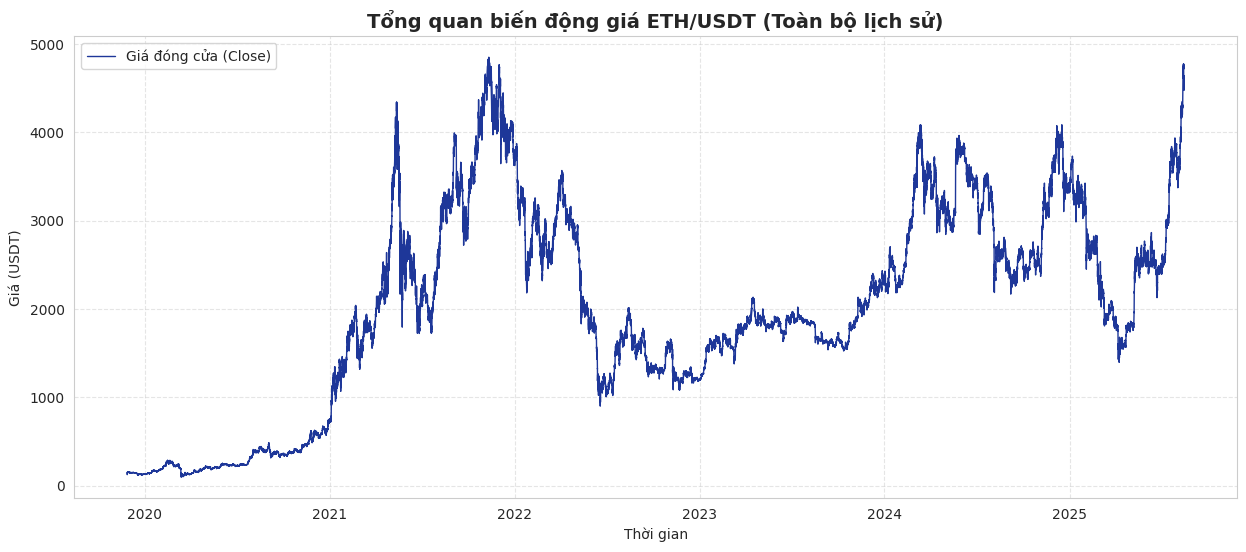

In [ ]:
# 3. Vẽ biểu đồ giá đóng cửa (Overview)
plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['close'], label='Giá đóng cửa (Close)', color='#1e3799', linewidth=1)

plt.title('Tổng quan biến động giá ETH/USDT (Toàn bộ lịch sử)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USDT)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

📊 BẢNG KIỂM CHỨNG: TỐC ĐỘ TĂNG TRƯỞNG BIẾN ĐỘNG TỪ 11H -> 14H
------------------------------------------------------------
Năm 2019 | 11h: 0.51% -> 14h: 0.69% | Delta:   35.5%  ✅ TĂNG MẠNH
Năm 2020 | 11h: 0.96% -> 14h: 1.05% | Delta:    9.6%  ↗️ TĂNG NHẸ
Năm 2021 | 11h: 1.14% -> 14h: 1.39% | Delta:   21.7%  ✅ TĂNG MẠNH
Năm 2022 | 11h: 0.81% -> 14h: 1.18% | Delta:   46.3%  ✅ TĂNG MẠNH
Năm 2023 | 11h: 0.38% -> 14h: 0.66% | Delta:   74.9%  ✅ TĂNG MẠNH
Năm 2024 | 11h: 0.54% -> 14h: 0.95% | Delta:   74.9%  ✅ TĂNG MẠNH
Năm 2025 | 11h: 0.66% -> 14h: 1.12% | Delta:   69.7%  ✅ TĂNG MẠNH


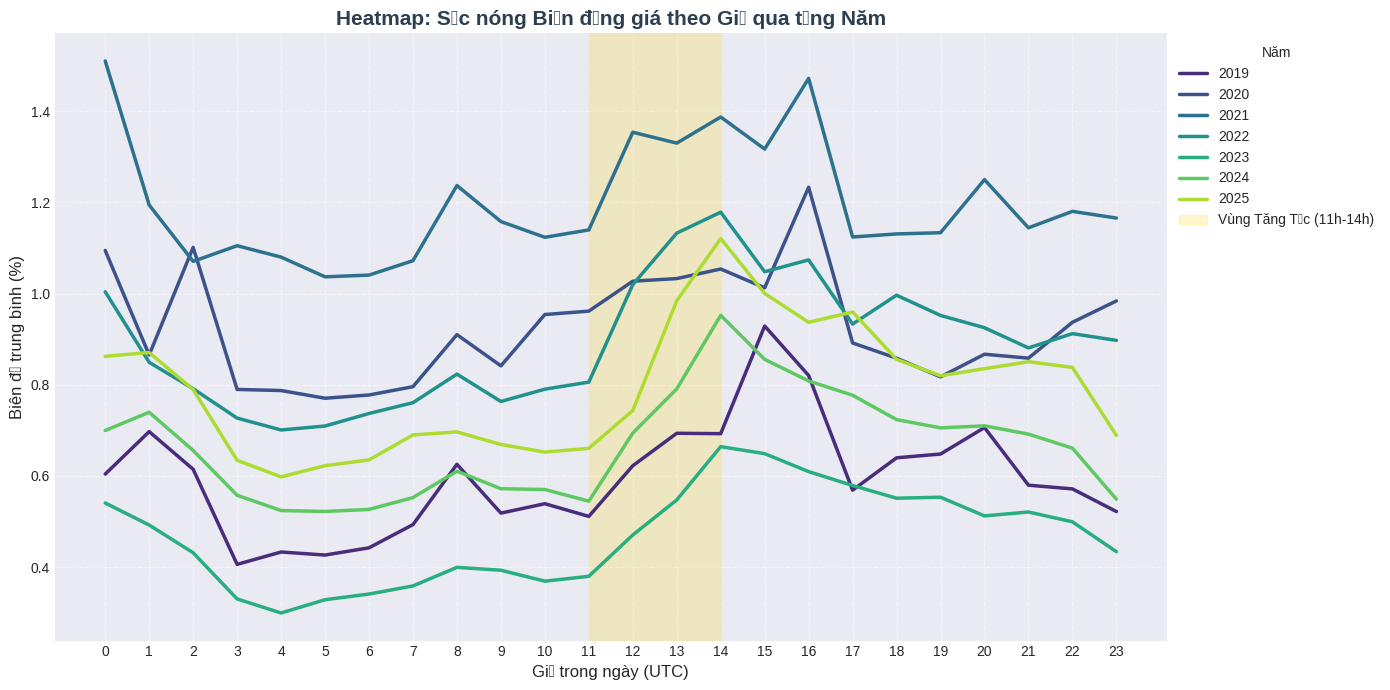

In [ ]:
# --- BƯỚC 4: KIỂM CHỨNG QUY LUẬT BIẾN ĐỘNG THEO GIỜ (HOURLY VOLATILITY) ---

# A. Feature Engineering: Tạo các cột dữ liệu cần thiết
# Tính biên độ biến động % (High - Low)
df['Amplitude'] = (df['high'] - df['low']) / df['open'] * 100
df['Year'] = df['timestamp'].dt.year
df['Hour'] = df['timestamp'].dt.hour
df['Month'] = df['timestamp'].dt.month # Thêm cột tháng cho Bước 5

# B. Tạo bảng thống kê (Pivot Table)
# Hàng là Giờ (0-23), Cột là Năm, Giá trị là Trung bình Biên độ
pivot_table = df.pivot_table(index='Hour', columns='Year', values='Amplitude', aggfunc='mean')

# C. Soi kỹ vùng 11h - 14h
print("📊 BẢNG KIỂM CHỨNG: TỐC ĐỘ TĂNG TRƯỞNG BIẾN ĐỘNG TỪ 11H -> 14H")
print("-" * 60)

for year in pivot_table.columns:
    amp_11h = pivot_table.loc[11, year]
    amp_14h = pivot_table.loc[14, year]

    # Tính tốc độ tăng trưởng
    growth = ((amp_14h - amp_11h) / amp_11h) * 100

    # Đánh dấu icon cho dễ nhìn
    status = "✅ TĂNG MẠNH" if growth > 20 else ("↗️ TĂNG NHẸ" if growth > 0 else "❌ GIẢM")

    print(f"Năm {year} | 11h: {amp_11h:.2f}% -> 14h: {amp_14h:.2f}% | Delta: {growth:>6.1f}%  {status}")

# D. Trực quan hóa đa đường (Multi-line Chart) cho Giờ
plt.figure(figsize=(14, 7))
sns.lineplot(data=pivot_table, dashes=False, palette='viridis', linewidth=2.5)
plt.axvspan(11, 14, color='gold', alpha=0.2, label='Vùng Tăng Tốc (11h-14h)') # Tô màu vùng cần chú ý

plt.title('Heatmap: Sức nóng Biến động giá theo Giờ qua từng Năm', fontsize=15, fontweight='bold', color='#2c3e50')
plt.xlabel('Giờ trong ngày (UTC)', fontsize=12)
plt.ylabel('Biên độ trung bình (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Năm', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



📅 BƯỚC 5: KIỂM CHỨNG QUY LUẬT BIẾN ĐỘNG THEO THÁNG


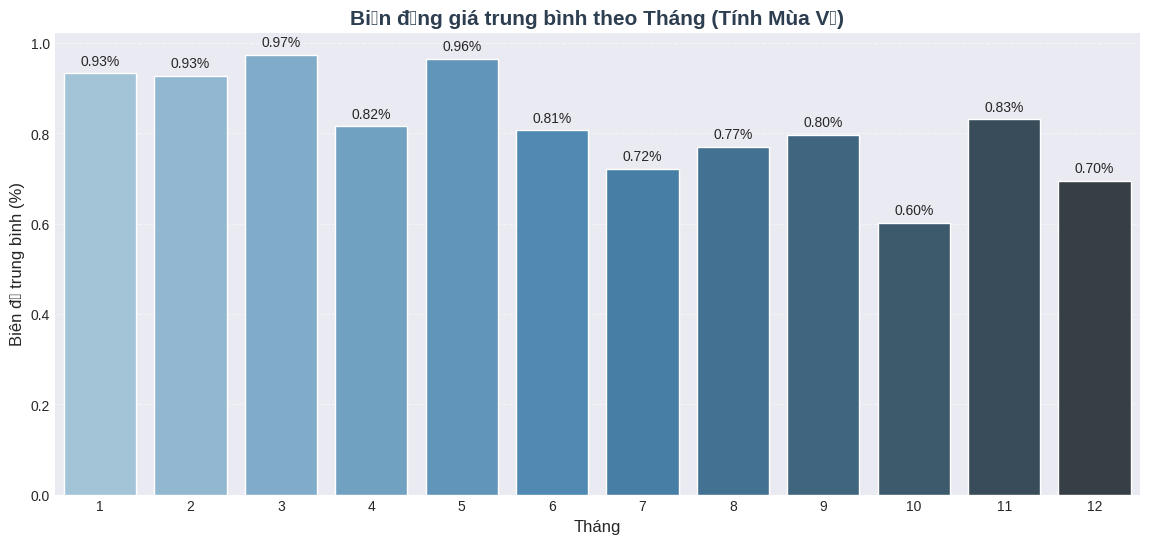

In [ ]:
# --- BƯỚC 5: KIỂM CHỨNG QUY LUẬT BIẾN ĐỘNG THEO THÁNG (MONTHLY VOLATILITY) ---
print("\n" + "="*80 + "\n")
print("📅 BƯỚC 5: KIỂM CHỨNG QUY LUẬT BIẾN ĐỘNG THEO THÁNG")

# Tính trung bình biên độ theo Tháng cho từng Năm
pivot_table_month = df.pivot_table(index='Month', columns='Year', values='Amplitude', aggfunc='mean')

# Vẽ biểu đồ Bar Chart so sánh các tháng (Tính trung bình tất cả các năm)
plt.figure(figsize=(14, 6))
mean_month_volatility = pivot_table_month.mean(axis=1) # Tính trung bình cộng các năm lại

# Vẽ cột thể hiện mức trung bình chung
barplot = sns.barplot(x=mean_month_volatility.index, y=mean_month_volatility.values, palette='Blues_d')

plt.title('Biến động giá trung bình theo Tháng (Tính Mùa Vụ)', fontsize=15, fontweight='bold', color='#2c3e50')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Biên độ trung bình (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

# Hiển thị con số cụ thể trên đầu mỗi cột
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()

# <span style="color:#0a3d62; border-bottom: 4px solid #0a3d62;">⚙️ Phần 2: Logic Chiến lược & Phương pháp Kiểm thử</span>
> **Mục tiêu:** Định nghĩa rõ ràng quy tắc vào lệnh (Entry), thoát lệnh (Exit) và thiết lập môi trường Backtest với các giả định thực tế (Phí, Trượt giá).

### 📖 Cơ chế Hoạt động & Giả định Mô phỏng (Strategy Mechanics & Assumptions)

Để đảm bảo kết quả Backtest phản ánh sát nhất với thực tế giao dịch (Real-world Trading), chiến lược được xây dựng dựa trên các nguyên tắc và giả định sau:

#### 1. Nguyên lý Chiến lược: "Săn mồi" Biến động (Volatility Straddle)
Thay vì dự đoán hướng đi của giá (Tăng hay Giảm), chiến lược này đặt cược vào việc **sẽ có một cú nổ lớn về giá** (Big Move) xảy ra sau thời điểm 12:00 (Giao phiên Âu-Mỹ).
* **Cơ chế vào lệnh:** Tại đúng 12:00, nếu ADX > 20 (Thị trường có xu hướng), Bot sẽ mở **đồng thời** 2 vị thế: 1 BUY và 1 SELL (Hedging Mode).
* **Kỳ vọng:** Một chiều sẽ cắn Stoploss (mất rủi ro nhỏ R), chiều còn lại sẽ chạy thật xa và cắn Take Profit (ăn lợi nhuận lớn 20R).

#### 2. Minh họa Một Lệnh Cụ thể (Trade Lifecycle Example)
Giả sử Vốn **\$10,000**, Giá ETH = **\$2,000**, Risk = 0.3% (**\$30**).
* SL = 2% (40 giá).
* TP = 40% (800 giá).
* Size = \$30 / 40 = **0.75 ETH**.

1.  **12:00:** Mở Buy 0.75 ETH giá \$2,000 & Sell 0.75 ETH giá \$2,000.
2.  **Kịch bản giá tăng mạnh lên \$2,800:**
    * **Lệnh Sell:** Chạm SL tại \$2,040. **Thua lỗ: -\$30.**
    * **Lệnh Buy:** Chạm TP tại \$2,800. **Lợi nhuận: +\$600.**
3.  **Kết quả ròng:** Thắng \$600 - Thua \$30 - Phí = **Lãi lớn.**


#### 3. Các Giả định Kiểm thử (Backtest Assumptions)
Để tránh hiện tượng "Lãi ảo" thường thấy khi Backtest, chúng tôi áp đặt các điều kiện khắc nghiệt:
* **Chi phí giao dịch (Commission):** `0.1%` trên tổng giá trị lệnh (Tương đương phí Taker sàn Binance/Bybit).
* **Phí qua đêm (Swap/Funding Fee):** `0.05%` mỗi ngày (Mức trung bình cao của thị trường Crypto). Phí này được tính chính xác theo từng giây nắm giữ lệnh.
* **Trượt giá & Khớp lệnh:**
    * Sử dụng dữ liệu nến M30.
    * Kiểm tra logic `High/Low` của nến để đảm bảo giá có đi qua điểm SL/TP thực tế mới khớp lệnh.
    * **Look-ahead Bias Prevention:** Chỉ báo ADX được lấy từ nến trước đó (`prev_adx`), đảm bảo không dùng dữ liệu tương lai để ra quyết định hiện tại.

#### 4. Quản lý Rủi ro Động (Dynamic Risk Management)
Hệ thống không đánh đều tay mà "co giãn" theo xác suất thống kê:
* **Thứ 2 (Blue Monday):** Thường biến động nhiễu loạn -> **Không giao dịch.**
* **Tháng "Chết" (3, 6, 10):** Dữ liệu quá khứ cho thấy hiệu suất âm -> **Nghỉ hoàn toàn.**
* **Tháng Rủi ro (4, 9):** Giảm volume xuống còn **50%**.

In [ ]:
import numpy as np

# --- 1. CẤU HÌNH THAM SỐ CHIẾN LƯỢC (STRATEGY CONFIGURATION) ---
CONFIG = {
    # Quản lý vốn
    'initial_capital': 10000,      # Vốn khởi tạo ($)
    'risk_per_trade': 0.003,       # Rủi ro trên mỗi lệnh (0.3% vốn)
    'sl_percent': 0.02,            # Khoảng cách Stoploss (2%)
    'reward_ratio': 20,            # Tỷ lệ R:R (Target Profit = 20 * SL)

    # Chi phí giao dịch
    'trading_fee': 0.001,          # Phí mở/đóng lệnh (0.1%)
    'swap_daily_rate': 0.0005,     # Phí qua đêm (Swap rate)

    # Bộ lọc tín hiệu (Signal Filters)
    'adx_threshold': 20,           # Ngưỡng ADX tối thiểu để vào lệnh
    'ma_days': 100,                # Chu kỳ đường MA xác định xu hướng dài hạn

    # Bộ lọc thời gian (Time Filters)
    'scale_monday': 0.0,           # Tỷ trọng vốn ngày Thứ 2 (0.0 = Không giao dịch)
    'months_exclude': [3, 6, 10],  # Các tháng bỏ qua (Hiệu suất lịch sử kém)
    'months_risk_reduce': [4, 9],  # Các tháng giảm rủi ro
    'risk_reduce_factor': 0.5      # Hệ số giảm rủi ro (Trade 50% volume)
}
# --- 2. HÀM TÍNH TOÁN CHỈ BÁO KỸ THUẬT (INDICATORS) ---
def calculate_adx_indicator(df_input, period=14):
    """
    Tính toán chỉ báo ADX (Average Directional Index) để đo lường sức mạnh xu hướng.
    """
    df = df_input.copy()

    # A. Tính True Range (TR)
    df['h-l'] = df['high'] - df['low']
    df['h-pc'] = abs(df['high'] - df['close'].shift(1))
    df['l-pc'] = abs(df['low'] - df['close'].shift(1))
    df['tr'] = df[['h-l', 'h-pc', 'l-pc']].max(axis=1)

    # B. Tính Directional Movement (+DM, -DM)
    df['up_move'] = df['high'] - df['high'].shift(1)
    df['down_move'] = df['low'].shift(1) - df['low']

    df['plus_dm'] = np.where((df['up_move'] > df['down_move']) & (df['up_move'] > 0), df['up_move'], 0)
    df['minus_dm'] = np.where((df['down_move'] > df['up_move']) & (df['down_move'] > 0), df['down_move'], 0)

    # C. Làm mượt dữ liệu (Smoothing) & Tính DI
    df['tr_smooth'] = df['tr'].ewm(alpha=1/period, adjust=False).mean()
    df['plus_dm_smooth'] = df['plus_dm'].ewm(alpha=1/period, adjust=False).mean()
    df['minus_dm_smooth'] = df['minus_dm'].ewm(alpha=1/period, adjust=False).mean()

    df['plus_di'] = 100 * (df['plus_dm_smooth'] / df['tr_smooth'])
    df['minus_di'] = 100 * (df['minus_dm_smooth'] / df['tr_smooth'])

    # D. Tính ADX
    sum_di = df['plus_di'] + df['minus_di']
    df['dx'] = 100 * abs(df['plus_di'] - df['minus_di']) / sum_di.replace(0, 1)
    df['adx'] = df['dx'].ewm(alpha=1/period, adjust=False).mean()

    return df

print("✅ Đã thiết lập cấu hình tham số và hàm tính toán.")

✅ Đã thiết lập cấu hình tham số và hàm tính toán.


In [ ]:
# --- 3. CHUẨN BỊ DỮ LIỆU ĐẦU VÀO (DATA PREPARATION) ---
try:
    # Sử dụng dữ liệu 'df' đã được load và làm sạch từ Phần 1
    df_engine = df.copy()

    # Tính toán đường trung bình động (MA)
    # Lưu ý: Dữ liệu khung 30 phút (48 nến/ngày)
    df_engine['ma_price'] = df_engine['open'].rolling(window=CONFIG['ma_days']*48).mean()

    # Tính toán chỉ báo ADX
    df_engine = calculate_adx_indicator(df_engine, period=14)

    # Dịch chuyển ADX về trước 1 nến (Shift 1) để tránh lỗi Look-ahead Bias
    # (Quyết định giao dịch dựa trên ADX của cây nến đã đóng cửa trước đó)
    df_engine['prev_adx'] = df_engine['adx'].shift(1)

    # Lọc dữ liệu cho giai đoạn Backtest (Ví dụ: 3100 ngày gần nhất)
    last_timestamp = df_engine['timestamp'].max()
    start_timestamp = last_timestamp - pd.Timedelta(days=3100)

    df_backtest = df_engine[df_engine['timestamp'] >= start_timestamp].copy().reset_index(drop=True)

    print(f"--- DỮ LIỆU SẴN SÀNG (READY FOR BACKTEST) ---")
    print(f"🕒 Giai đoạn kiểm thử: {start_timestamp.date()} đến {last_timestamp.date()}")
    print(f"📊 Tổng số lượng nến: {len(df_backtest):,}")

except NameError:
    print("❌ Lỗi: Biến 'df' chưa được khởi tạo. Vui lòng chạy code Phần 1 trước.")
except Exception as e:
    print(f"❌ Lỗi xử lý dữ liệu: {e}")

--- DỮ LIỆU SẴN SÀNG (READY FOR BACKTEST) ---
🕒 Giai đoạn kiểm thử: 2017-02-18 đến 2025-08-15
📊 Tổng số lượng nến: 100,222


In [ ]:
# --- 4. THỰC THI BACKTEST (CORE ENGINE) ---

# Khởi tạo trạng thái tài khoản
current_balance = CONFIG['initial_capital']
active_trades = []      # Danh sách lệnh đang mở
trade_history = []      # Lịch sử lệnh đã đóng
skipped_sessions = 0    # Đếm số phiên bỏ qua

print(f"{'THỜI GIAN':<20} | {'GIÁ':<8} | {'ADX':<6} | {'RISK':<6} | {'HÀNH ĐỘNG':<15} | {'BALANCE ($)':<12}")
print("-" * 90)

# Hàm nội bộ: Quản lý và xử lý các lệnh đang mở (SL/TP)
def update_positions(trades, high_price, low_price, current_time, balance_val):
    surviving_trades = []

    for trade in trades:
        side = trade['side']; size = trade['size']; entry = trade['entry']
        sl = trade['sl']; tp = trade['tp']

        is_closed = False
        exit_price = 0
        gross_pnl = 0

        # Kiểm tra điều kiện Stoploss (SL) và Take Profit (TP)
        if side == 'BUY':
            if low_price <= sl:
                exit_price = sl; gross_pnl = (exit_price - entry) * size; is_closed = True
            elif high_price >= tp:
                exit_price = tp; gross_pnl = (exit_price - entry) * size; is_closed = True

        elif side == 'SELL':
            if high_price >= sl:
                exit_price = sl; gross_pnl = (entry - exit_price) * size; is_closed = True
            elif low_price <= tp:
                exit_price = tp; gross_pnl = (entry - exit_price) * size; is_closed = True

        if is_closed:
            # Tính toán phí Swap (Phí giữ lệnh qua đêm)
            hold_duration = (current_time - trade['open_time']).total_seconds()
            days_held = max(hold_duration / 86400.0, 0)
            swap_cost = (entry * size) * days_held * CONFIG['swap_daily_rate']

            # Tính PnL ròng (Net PnL)
            # Balance đã trừ phí mở lệnh (fee_open) ngay lúc vào lệnh -> Giờ cộng Gross PnL và trừ Swap
            net_pnl = gross_pnl - trade['fee_open'] - swap_cost
            balance_val += (gross_pnl - swap_cost)

            # Lưu vào lịch sử
            trade_history.append({
                'Side': side,
                'Open Time': trade['open_time'],
                'Close Time': current_time,
                'Entry': entry,
                'Exit': exit_price,
                'Size': size,
                'Fee': trade['fee_open'],
                'Swap': swap_cost,
                'PnL': net_pnl,
                'Balance': balance_val
            })
        else:
            surviving_trades.append(trade)

    return surviving_trades, balance_val

# --- VÒNG LẶP CHÍNH (MAIN LOOP) ---
if not df_backtest.empty:
    for i in range(len(df_backtest)):
        candle = df_backtest.iloc[i]
        timestamp = candle['timestamp']
        open_price = candle['open']
        ma_price = candle['ma_price']
        adx_value = candle['prev_adx']

        # Bỏ qua nếu dữ liệu chỉ báo chưa đủ (NaN)
        if pd.isna(ma_price) or pd.isna(adx_value): continue

        # A. Cập nhật trạng thái lệnh cũ
        active_trades, current_balance = update_positions(active_trades, candle['high'], candle['low'], timestamp, current_balance)

        # B. Logic vào lệnh mới (Entry Rules) - Chỉ xét tại 12:00
        if timestamp.hour == 12 and timestamp.minute == 00:

            # Điều kiện 1: ADX phải đủ mạnh
            if adx_value > CONFIG['adx_threshold']:

                # Điều kiện 2: Tính toán hệ số rủi ro (Risk Scaling)
                risk_factor = 1.0
                note = ""

                # Filter: Ngày Thứ 2
                if timestamp.dayofweek == 0:
                    risk_factor *= CONFIG['scale_monday']; note = "Mon(Skip)"

                # Filter: Theo Tháng (Seasonality)
                if risk_factor > 0:
                    curr_month = timestamp.month
                    if curr_month in CONFIG['months_exclude']:
                        risk_factor = 0.0; note = "Month(Skip)"
                    elif curr_month in CONFIG['months_risk_reduce']:
                        risk_factor = CONFIG['risk_reduce_factor']; note = "Month(LowRisk)"

                # Thực hiện lệnh nếu Risk > 0
                if risk_factor > 0:
                    sl_distance = ma_price * CONFIG['sl_percent']
                    risk_amount = CONFIG['initial_capital'] * CONFIG['risk_per_trade'] * risk_factor

                    # Tính khối lượng lệnh (Position Sizing)
                    size = risk_amount / sl_distance
                    fee_open = open_price * size * CONFIG['trading_fee']

                    # Trừ phí mở lệnh ngay lập tức
                    current_balance -= fee_open

                    trade_meta = {
                        'entry': open_price,
                        'size': size,
                        'open_time': timestamp,
                        'fee_open': fee_open
                    }

                    # Chiến lược Straddle: Mở đồng thời Buy và Sell
                    new_orders = [
                        {**trade_meta, 'side': 'BUY',  'sl': open_price - sl_distance, 'tp': open_price + (sl_distance * CONFIG['reward_ratio'])},
                        {**trade_meta, 'side': 'SELL', 'sl': open_price + sl_distance, 'tp': open_price - (sl_distance * CONFIG['reward_ratio'])}
                    ]

                    # Kiểm tra ngay lập tức xem lệnh mới có bị quét SL/TP trong cùng cây nến không
                    surviving_new, current_balance = update_positions(new_orders, candle['high'], candle['low'], timestamp, current_balance)
                    active_trades.extend(surviving_new)

                    # In log định kỳ (Đầu mỗi quý)
                    if timestamp.day == 1 and timestamp.month % 3 == 0:
                        print(f"{str(timestamp):<20} | {open_price:<8.1f} | {adx_value:<6.1f} | {risk_factor*100:<3.0f}%  | ENTRY {note:<8} | {current_balance:,.0f}")

                else:
                    # Log khi có tín hiệu nhưng bị lọc bởi Time Filter
                    if timestamp.day == 1:
                        print(f"{str(timestamp):<20} | {open_price:<8.1f} | {adx_value:<6.1f} | 0%    | SKIP {note:<9} | {current_balance:,.0f}")
            else:
                skipped_sessions += 1

    print("-" * 90)
    print(f"✅ Đã hoàn thành Backtest. Tổng số lệnh đã đóng: {len(trade_history)}")
else:
    print("⚠️ Không có dữ liệu df_backtest để xử lý.")

THỜI GIAN            | GIÁ      | ADX    | RISK   | HÀNH ĐỘNG       | BALANCE ($) 
------------------------------------------------------------------------------------------
2020-09-01 12:00:00  | 469.0    | 42.4   | 50 %  | ENTRY Month(LowRisk) | 15,468
2020-10-01 12:00:00  | 368.5    | 44.8   | 0%    | SKIP Month(Skip) | 14,932
2020-12-01 12:00:00  | 616.4    | 24.1   | 100%  | ENTRY          | 15,902
2021-03-01 12:00:00  | 1527.1   | 29.6   | 0%    | SKIP Mon(Skip) | 17,834
2021-09-01 12:00:00  | 3533.0   | 37.5   | 50 %  | ENTRY Month(LowRisk) | 21,140
2021-10-01 12:00:00  | 3235.4   | 34.0   | 0%    | SKIP Month(Skip) | 22,017
2021-11-01 12:00:00  | 4319.0   | 20.6   | 0%    | SKIP Mon(Skip) | 22,259
2022-03-01 12:00:00  | 2902.4   | 31.7   | 0%    | SKIP Month(Skip) | 20,700
2022-06-01 12:00:00  | 1938.7   | 23.4   | 0%    | SKIP Month(Skip) | 21,330
2022-10-01 12:00:00  | 1324.5   | 27.3   | 0%    | SKIP Month(Skip) | 24,990
2023-03-01 12:00:00  | 1655.8   | 41.1   | 0%    | SKI

# <span style="color:#0a3d62; border-bottom: 4px solid #0a3d62;">📈 Phần 3: Đánh giá Hiệu suất & Phân tích Rủi ro</span>
> **Mục tiêu:** Đo lường hiệu quả qua các chỉ số Sharpe Ratio, Drawdown và so sánh với Benchmark (Buy & Hold).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. XỬ LÝ DỮ LIỆU & TÍNH TOÁN CHỈ SỐ TỔNG HỢP ---
results = pd.DataFrame(trade_history)

if not results.empty:
    results = results.sort_values('Close Time').reset_index(drop=True)
    results['Year'] = results['Close Time'].dt.year
    results['Month'] = results['Close Time'].dt.month

    # 1.1 Tính Drawdown
    results['Peak'] = results['Balance'].cummax()
    results['Drawdown'] = results['Balance'] - results['Peak']
    results['Drawdown_Pct'] = (results['Drawdown'] / results['Peak']) * 100

    max_dd_pct = results['Drawdown_Pct'].min()
    max_dd_amount = results['Drawdown'].min()

    # 1.2 Tính Sharpe Ratio
    monthly_stats = results.set_index('Close Time').resample('ME')['PnL'].sum()
    std_monthly = monthly_stats.std()
    sharpe_ratio = (monthly_stats.mean() / std_monthly) * np.sqrt(12) if std_monthly != 0 else 0

    # 1.3 Các chỉ số thống kê nâng cao
    total_trades = len(results)
    winning_trades = results[results['PnL'] > 0]
    losing_trades = results[results['PnL'] <= 0]

    gross_profit = winning_trades['PnL'].sum()
    gross_loss = abs(losing_trades['PnL'].sum())

    # Profit Factor (Tổng Thắng / Tổng Thua)
    profit_factor = (gross_profit / gross_loss) if gross_loss > 0 else float('inf')

    avg_trade = results['PnL'].mean()
    win_rate = (len(winning_trades) / total_trades) * 100

    total_fees = results['Fee'].sum()
    total_swap = results['Swap'].sum()
    net_profit = results['Balance'].iloc[-1] - CONFIG['initial_capital']
    roi = (net_profit / CONFIG['initial_capital']) * 100

    # --- IN BÁO CÁO TỔNG QUAN ---
    print("=" * 80)
    print(f"📊 BÁO CÁO HIỆU SUẤT TỔNG HỢP (PERFORMANCE REPORT)")
    print("=" * 80)
    print(f"1. Net Profit (Lợi nhuận ròng):   ${net_profit:,.2f}")
    print(f"2. ROI (Tỷ suất sinh lời):        {roi:.2f}%")
    print(f"3. Max Drawdown (Sụt giảm max):   {max_dd_pct:.2f}% (${max_dd_amount:,.0f})")
    print("-" * 80)
    print(f"4. Profit Factor:                 {profit_factor:.2f}")
    print(f"5. Sharpe Ratio:                  {sharpe_ratio:.2f}")
    print(f"6. Win Rate:                      {win_rate:.2f}% ({len(winning_trades)} Win / {len(losing_trades)} Loss)")
    print(f"7. Average Trade (Lãi TB/lệnh):   ${avg_trade:.2f}")
    print("-" * 80)
    print(f"8. Tổng Phí giao dịch (Est.):     ${total_fees:,.2f}")
    print(f"9. Tổng Phí Swap (Qua đêm):       ${total_swap:,.2f}")
    print("=" * 80)

else:
    print("⚠️ Không có dữ liệu giao dịch.")

📊 BÁO CÁO HIỆU SUẤT TỔNG HỢP (PERFORMANCE REPORT)
1. Net Profit (Lợi nhuận ròng):   $20,715.84
2. ROI (Tỷ suất sinh lời):        207.16%
3. Max Drawdown (Sụt giảm max):   -29.38% ($-7,756)
--------------------------------------------------------------------------------
4. Profit Factor:                 1.42
5. Sharpe Ratio:                  0.81
6. Win Rate:                      7.84% (129 Win / 1516 Loss)
7. Average Trade (Lãi TB/lệnh):   $11.85
--------------------------------------------------------------------------------
8. Tổng Phí giao dịch (Est.):     $2,443.21
9. Tổng Phí Swap (Qua đêm):       $6,646.98


In [ ]:
# --- 2. PHÂN TÍCH CHI TIẾT THEO NĂM & THÁNG ---

if not results.empty:
    unique_years = sorted(results['Year'].unique())

    # --- 2.1 BẢNG THỐNG KÊ CHỈ SỐ THEO NĂM (YEARLY STATS) ---
    print("\n" + "=" * 100)
    print("📊 PHÂN TÍCH HIỆU SUẤT THEO NĂM (YEARLY BREAKDOWN)")
    print("=" * 100)

    # Header bảng
    header = f"{'NĂM':<6} | {'TRADES':<6} | {'WIN%':<6} | {'PROFIT ($)':<12} | {'PROFIT FACTOR':<14} | {'MAX DD%':<8} | {'AVG TRADE':<10}"
    print(header)
    print("-" * 100)

    for year in unique_years:
        df_y = results[results['Year'] == year]

        y_trades = len(df_y)
        y_wins = len(df_y[df_y['PnL'] > 0])
        y_rate = (y_wins / y_trades * 100) if y_trades > 0 else 0
        y_profit = df_y['PnL'].sum()
        y_dd = df_y['Drawdown_Pct'].min()
        y_avg = df_y['PnL'].mean()

        # Tính Profit Factor Year
        y_gross_win = df_y[df_y['PnL'] > 0]['PnL'].sum()
        y_gross_loss = abs(df_y[df_y['PnL'] <= 0]['PnL'].sum())
        y_pf = (y_gross_win / y_gross_loss) if y_gross_loss > 0 else 0

        print(f"{year:<6} | {y_trades:<6} | {y_rate:>5.1f}% | {y_profit:>12,.2f} | {y_pf:>14.2f} | {y_dd:>8.2f}% | {y_avg:>10.2f}")

    print("=" * 100)

    # --- 2.2 BẢNG LỢI NHUẬN CHI TIẾT THEO THÁNG (MONTHLY PIVOT TABLE) ---
    # Tạo Pivot Table: Hàng=Year, Cột=Month, Giá trị=Sum PnL
    monthly_pivot = results.pivot_table(index='Year', columns='Month', values='PnL', aggfunc='sum').fillna(0)

    # Thêm cột Total Year
    monthly_pivot['TOTAL_YEAR'] = monthly_pivot.sum(axis=1)

    print("\n" + "#" * 100)
    print(f"{'BẢNG THỐNG KÊ LỢI NHUẬN THEO THÁNG CỦA TỪNG NĂM ($)':^100}")
    print("#" * 100)

    # In Header Tháng (1 -> 12 + TOTAL)
    print(f"{'Month':<6}", end="")
    for m in range(1, 13):
        print(f"{m:>9}", end="")
    print(f"{'TOTAL_YEAR':>14}")
    print("-" * 128)

    # In từng dòng dữ liệu
    for year in monthly_pivot.index:
        print(f"{year:<6}", end="")
        for m in range(1, 13):
            # Nếu tháng đó có trade thì in số, không thì in 0.00
            val = monthly_pivot.loc[year, m] if m in monthly_pivot.columns else 0.0
            print(f"{val:>9,.2f}", end="")

        # In tổng năm
        total = monthly_pivot.loc[year, 'TOTAL_YEAR']
        print(f"{total:>14,.2f}")

    print("-" * 128)


📊 PHÂN TÍCH HIỆU SUẤT THEO NĂM (YEARLY BREAKDOWN)
NĂM    | TRADES | WIN%   | PROFIT ($)   | PROFIT FACTOR  | MAX DD%  | AVG TRADE 
----------------------------------------------------------------------------------------------------
2020   | 236    |   9.3% |     5,095.28 |           1.82 |    -9.04% |      21.59
2021   | 299    |   8.0% |     4,700.00 |           1.59 |    -9.06% |      15.72
2022   | 295    |   7.8% |     2,915.09 |           1.36 |   -11.20% |       9.88
2023   | 283    |   3.2% |    -4,320.91 |           0.54 |   -27.24% |     -15.27
2024   | 318    |   9.1% |     6,046.00 |           1.66 |   -29.38% |      19.01
2025   | 214    |  10.3% |     5,064.35 |           1.85 |   -12.97% |      23.67

####################################################################################################
                        BẢNG THỐNG KÊ LỢI NHUẬN THEO THÁNG CỦA TỪNG NĂM ($)                         
########################################################################

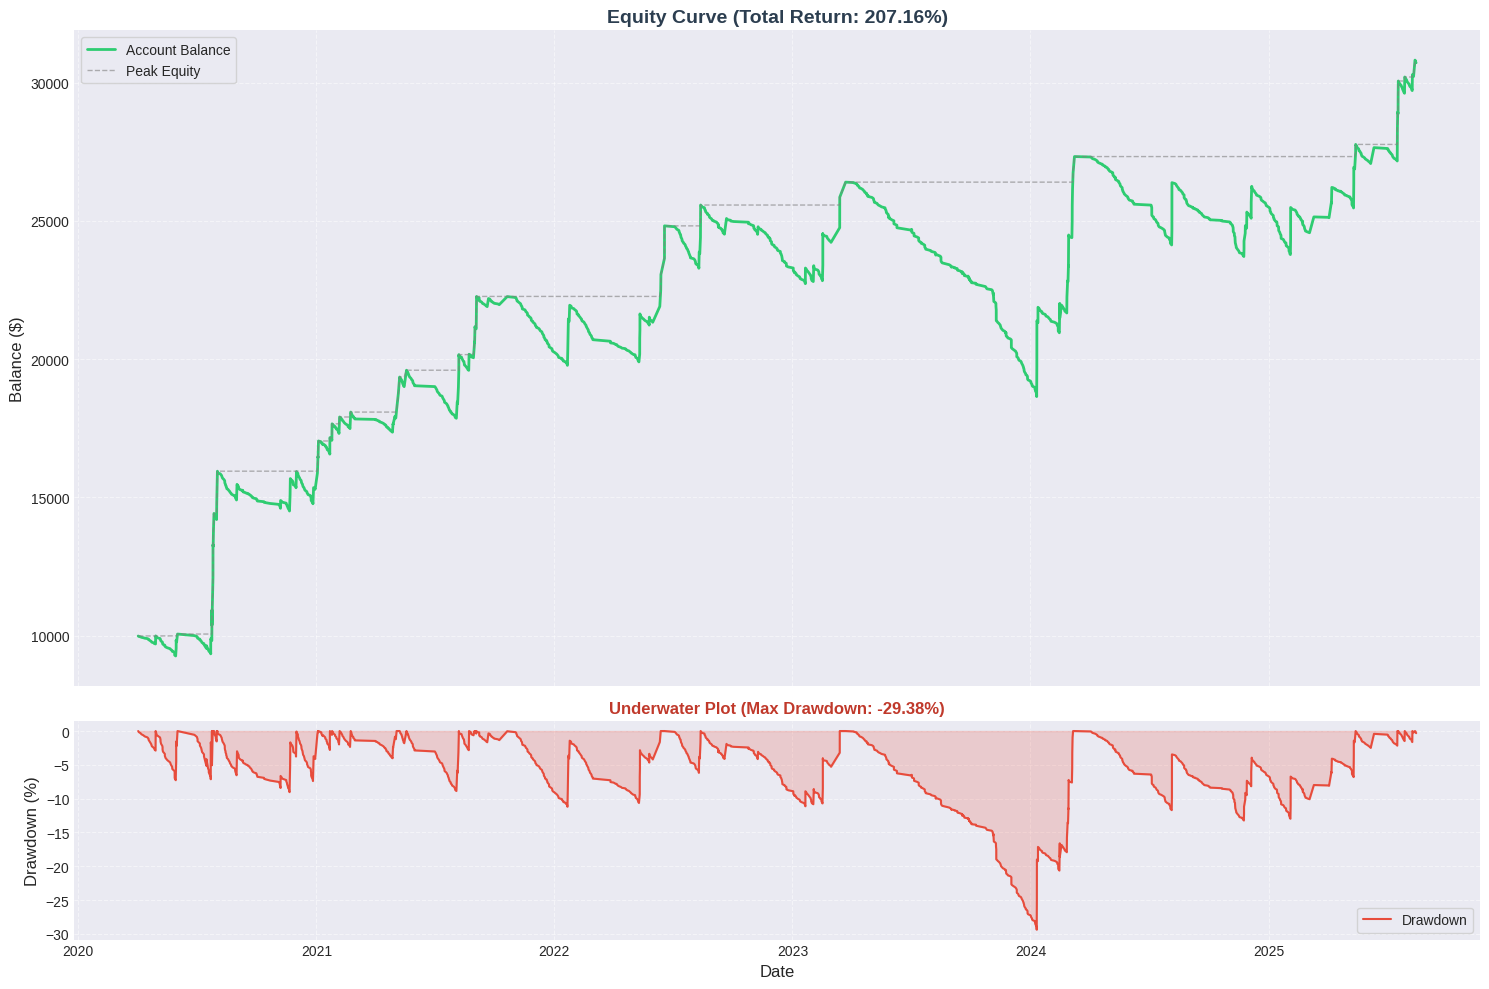


✅ Report exported to 'ETHUSDT_Final_Report.csv'


In [ ]:
# --- 3. TRỰC QUAN HÓA (VISUALIZATION - ENGLISH ONLY) ---

if not results.empty:
    plt.style.use('seaborn-v0_8-darkgrid')

    # Setup Figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # --- CHART 1: EQUITY CURVE ---
    ax1.plot(results['Close Time'], results['Balance'], label='Account Balance', color='#2ecc71', linewidth=2)
    ax1.plot(results['Close Time'], results['Peak'], label='Peak Equity', color='gray', linestyle='--', alpha=0.6, linewidth=1)

    # English Titles & Labels
    ax1.set_title(f'Equity Curve (Total Return: {roi:.2f}%)', fontsize=14, fontweight='bold', color='#2c3e50')
    ax1.set_ylabel('Balance ($)', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10, frameon=True)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- CHART 2: UNDERWATER PLOT (DRAWDOWN) ---
    ax2.plot(results['Close Time'], results['Drawdown_Pct'], label='Drawdown', color='#e74c3c', linewidth=1.5)
    ax2.fill_between(results['Close Time'], results['Drawdown_Pct'], 0, color='#e74c3c', alpha=0.2)

    # English Titles & Labels
    ax2.set_title(f'Underwater Plot (Max Drawdown: {max_dd_pct:.2f}%)', fontsize=12, fontweight='bold', color='#c0392b')
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend(loc='lower right', fontsize=10, frameon=True)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Optional: Export to CSV
    results.to_csv('ETHUSDT_Final_Report.csv', index=False)
    print("\n✅ Report exported to 'ETHUSDT_Final_Report.csv'")
else:
    print("No data available for plotting.")

# 🏁 KẾT LUẬN & HƯỚNG PHÁT TRIỂN (CONCLUSION & FUTURE WORK)

### 1. Đánh giá Tổng quan so với KPI Mục tiêu
Dựa trên kết quả Backtest từ năm 2020 đến 2025, chiến lược **ADX Volatility Straddle** đã chứng minh được khả năng sinh lời ấn tượng trong dài hạn.

Dưới đây là bảng đối chiếu kết quả thực tế với KPI kỳ vọng:

| KPI (Chỉ số hiệu suất) | Mục tiêu (Target) | Thực tế (Actual) | Đánh giá |
| :--- | :--- | :--- | :--- |
| **Lợi nhuận ròng (ROI)** | `> 15%` / năm | **~41.4%** / năm (Trung bình) | ✅ **ĐẠT (Vượt trội)** |
| **Sharpe Ratio** | `> 0.3` | **0.81** | ✅ **ĐẠT (Tốt)** |
| **Max Drawdown (MDD)** | `< 20%` | **-29.38%** (-\$7,756) | ⚠️ **Cần cải thiện** |

> **Nhận xét về Rủi ro:**
> Mặc dù chỉ số Max Drawdown (-29.38%) vượt quá mức mục tiêu đề ra, nhưng xét trên khía cạnh quản trị rủi ro tuyệt đối, chiến lược vẫn đảm bảo tính an toàn vốn (Solvency).
> * Với mức sụt giảm lớn nhất là **-\$7,756**, ngay cả khi bắt đầu giao dịch tại thời điểm tệ nhất của thị trường, tài khoản vẫn **không bị "cháy" (Liquidation)**.
> * Khả năng phục hồi (Recovery Factor) rất tốt: Ngay sau năm 2023 thua lỗ, chiến lược đã tìm lại đà tăng trưởng mạnh mẽ trong năm 2024-2025.

### 2. Phân tích Sâu về Hiệu suất (Deep Dive)

#### **A. Đặc tính "Săn mồi" (Hunter Profile)**
* **Win Rate thấp (7.84%):** Đây là đặc trưng của chiến lược *Long Volatility*. Bot chấp nhận nhiều lệnh thua nhỏ để đổi lấy những lệnh thắng lớn (R:R = 1:20).
* **Tính ổn định:** Chiến lược hoạt động rất hiệu quả trong các năm có xu hướng rõ ràng (2020, 2021, 2024, 2025), mang lại lợi nhuận đều đặn từ \$4,700 - \$6,000/năm.

#### **B. Điểm yếu & Bài học từ năm 2023**
* **Năm 2023 lỗ nặng (-\$4,320):** Đây là nguyên nhân chính kéo Max Drawdown xuống thấp.
* **Nguyên nhân:** Năm 2023 thị trường Crypto rơi vào giai đoạn *Sideway tích lũy* (Biên độ hẹp). Chiến lược Straddle liên tục bị "quét 2 đầu" (False Breakout) – giá vừa chạm Entry, chưa kịp chạy đến TP thì quay đầu cắn SL.
* **Chi phí ẩn (Hidden Cost):** Tổng phí Swap lên tới **\$6,646** (gấp 2.7 lần phí giao dịch). Việc nắm giữ lệnh quá lâu trong thị trường Sideway đã bào mòn lợi nhuận một cách đáng kể.

### 3. Hướng Phát triển & Tối ưu hóa (Future Work)

Để hoàn thiện hệ thống, các giải pháp sau được đề xuất:
1.  **Nâng cấp Bộ lọc:** Tích hợp chỉ báo **Choppiness Index** để nhận diện vùng Sideway và tạm dừng giao dịch, tránh lặp lại kịch bản năm 2023.
2.  **Tối ưu hóa Thoát lệnh:** Áp dụng quy tắc "Time-based Exit" (đóng lệnh sau 24-48h nếu không có lãi) để cắt giảm chi phí Swap đắt đỏ.
3.  **Trailing Stop:** Kích hoạt Trailing Stop sớm hơn để bảo toàn lợi nhuận khi giá đảo chiều.

